# Convolutionary Neural Network Model for Vehicle Classification

1.  A CNN scans the image in small patches (filters) to detect simple patterns first — edges, colors, and textures.

2. Each layer stacks on the previous one, combining simple patterns into more complex shapes — wheels, windows, wings — the deeper you go.

3. At the end, it takes all these learned features and votes on which class (car, bus, bicycle, etc.) they most likely belong to.

In [2]:
%pip install tensorflow kagglehub pillow matplotlib

## Dataset Link from Kaggle

https://www.kaggle.com/datasets/mmohaiminulislam/vehicles-image-dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mmohaiminulislam/vehicles-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.64G/1.64G [00:14<00:00, 123MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mmohaiminulislam/vehicles-image-dataset/versions/1


In [4]:
import os

# Show files
for root, dirs, files in os.walk(path):
    print(root)
    print(dirs[:5])
    break

/root/.cache/kagglehub/datasets/mmohaiminulislam/vehicles-image-dataset/versions/1
['vehicle_data']


In [5]:
%ls "{path}/vehicle_data/"

airplane/   boat/  fire_truck/  jet_ski/     rickshaw/  skateboard/  unicycle/
ambulance/  bus/   helicopter/  kayak/       scooter/   tractor/     van/
bicycle/    car/   hovercraft/  motorcycle/  segway/    truck/


In [6]:
%pip install split-folders

In [7]:
import splitfolders
import os

In [8]:
input_folder = os.path.join(path, "vehicle_data")
output_folder = os.path.join(path, "split_dataset")

## Splitting Dataset in 80% Trainuing, 10% Testing, 10% Validation

In [9]:
splitfolders.ratio(
    input=input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.8, 0.1, 0.1),
    group_prefix=None,
    move=False
)

Copying files: 3698 files [00:09, 402.35 files/s]


Converting 4 Channel to 3 Channels

In [10]:
from PIL import Image
import os

dataset_dir = output_folder

bad = []

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")):
            p = os.path.join(root, file)

            try:
                img = Image.open(p)
                if img.mode != "RGB":
                    bad.append((p, img.mode))
            except Exception as e:
                bad.append((p, str(e)))

print("Bad Images:", len(bad))

for b in bad[:50]:
    print(b)

Bad Images: 311
('/root/.cache/kagglehub/datasets/mmohaiminulislam/vehicles-image-dataset/versions/1/split_dataset/val/bicycle/3d28ee7b-f3f4-4b98-9099-1ff806fddd68.png', 'RGBA')
('/root/.cache/kagglehub/datasets/mmohaiminulislam/vehicles-image-dataset/versions/1/split_dataset/val/bicycle/3d2980a8-a404-412d-b599-895dc1f96e55.png', 'RGBA')
('/root/.cache/kagglehub/datasets/mmohaiminulislam/vehicles-image-dataset/versions/1/split_dataset/val/van/f436090a-9a9e-4253-a90e-0aafd2d858d8.png', 'RGBA')
('/root/.cache/kagglehub/datasets/mmohaiminulislam/vehicles-image-dataset/versions/1/split_dataset/val/unicycle/fabe8966-b8e1-41c4-a59c-c5d8ece2edec.png', 'RGBA')
('/root/.cache/kagglehub/datasets/mmohaiminulislam/vehicles-image-dataset/versions/1/split_dataset/val/unicycle/7f57d365-467e-4c25-98fb-bc28cf6ce83f.png', 'RGBA')
('/root/.cache/kagglehub/datasets/mmohaiminulislam/vehicles-image-dataset/versions/1/split_dataset/val/unicycle/cb29519c-76b3-49d0-a05e-5c6748cb15ab.png', 'RGBA')
('/root/.cach

In [11]:
from PIL import Image
import os

dataset_dir = os.path.join(path, "split_dataset")

converted = 0
failed = []

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp")):
            img_path = os.path.join(root, file)

            try:
                img = Image.open(img_path)

                # Convert every non-RGB image
                if img.mode != "RGB":
                    img = img.convert("RGB")
                    img.save(img_path)
                    converted += 1

            except Exception as e:
                failed.append((img_path, str(e)))

print(f"Converted: {converted}")
print(f"Failed: {len(failed)}")

if failed:
    print(failed[:10])

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Converted: 299
Failed: 0


In [12]:
for folder in ["train", "val", "test"]:
    print(f"\n{folder.upper()}")
    print(os.listdir(os.path.join(output_folder, folder))[:5])


TRAIN
['bicycle', 'van', 'unicycle', 'bus', 'tractor']

VAL
['bicycle', 'van', 'unicycle', 'bus', 'tractor']

TEST
['bicycle', 'van', 'unicycle', 'bus', 'tractor']


In [13]:
train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

In [14]:
import os
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32


train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Number of Classes:", len(class_names))
print("Classes:", class_names)

Found 2946 files belonging to 20 classes.
Found 362 files belonging to 20 classes.
Found 384 files belonging to 20 classes.
Number of Classes: 20
Classes: ['airplane', 'ambulance', 'bicycle', 'boat', 'bus', 'car', 'fire_truck', 'helicopter', 'hovercraft', 'jet_ski', 'kayak', 'motorcycle', 'rickshaw', 'scooter', 'segway', 'skateboard', 'tractor', 'truck', 'unicycle', 'van']


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Dropout, Rescaling,
    RandomFlip, RandomRotation, RandomZoom, RandomContrast,
    RandomTranslation
)
from tensorflow.keras.regularizers import l2

num_classes = len(class_names)


model = Sequential([
    Input(shape=(128, 128, 3)),

    # Augmentation
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    Rescaling(1./255),

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.2),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    # Block 4
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.35),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,89

 Total params: 425,812 (1.62 MB)

 Trainable params: 424,852 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=40
)

Epoch 1/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 80s 167ms/step - accuracy: 0.0957 - loss: 3.0573 - val_accuracy: 0.0495 - val_loss: 4.1282
Epoch 2/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.1392 - loss: 2.8254 - val_accuracy: 0.0521 - val_loss: 4.5815
Epoch 3/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.1555 - loss: 2.7337 - val_accuracy: 0.0573 - val_loss: 4.7157
Epoch 4/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.1901 - loss: 2.6752 - val_accuracy: 0.0729 - val_loss: 4.4955
Epoch 5/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.1816 - loss: 2.6212 - val_accuracy: 0.1068 - val_loss: 3.4489
Epoch 6/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.2145 - loss: 2.5691 - val_accuracy: 0.1510 - val_loss: 2.7108
Epoch 7/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.2305 - loss: 2.5115 - val_accuracy: 0.2188 - val_loss: 2.5099
Epoch 8/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.2349 - loss: 2.4640 - val_accuracy: 0.1927 

In [18]:
loss, accuracy = model.evaluate(test_ds)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4297 - loss: 2.2150
Test Loss: 2.2150
Test Accuracy: 0.4297


In [19]:
model.save("cars_cnn.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


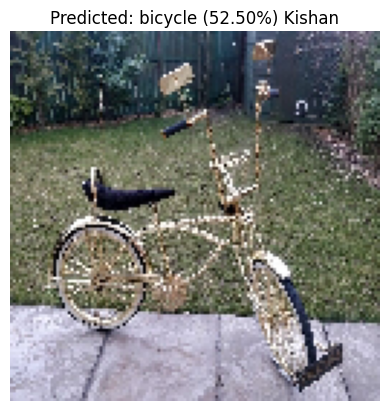

In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

def predict_image(img_path, model, class_names, img_size=128):
    # Load and resize image
    img = image.load_img(img_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    # Show image with prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%) Kishan")
    plt.show()

    return predicted_class, confidence


# Usage
# Construct a valid path to a bicycle image from the test set
bicycle_test_dir = os.path.join(test_dir, 'bicycle')

# Get the first image file from that directory
image_files = os.listdir(bicycle_test_dir)
if image_files:
    sample_bicycle_image = image_files[0]
    image_path_to_predict = os.path.join(bicycle_test_dir, sample_bicycle_image)

    predict_image(image_path_to_predict, model, class_names)
else:
    print(f"No image files found in {bicycle_test_dir}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


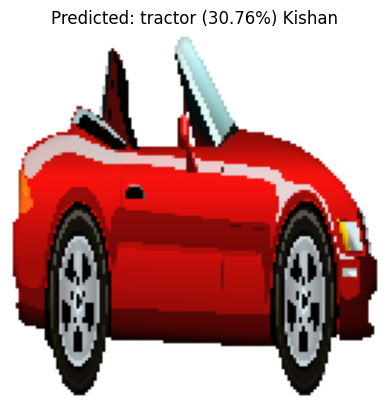

In [21]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os # Added os import

def predict_image(img_path, model, class_names, img_size=128):
    # Load and resize image
    img = image.load_img(img_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    # Show image with prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%) Kishan")
    plt.show()

    return predicted_class, confidence


# Usage
# Re-define necessary path variables from the notebook's state
path = '/root/.cache/kagglehub/datasets/mmohaiminulislam/vehicles-image-dataset/versions/1'
output_folder = os.path.join(path, "split_dataset")
test_dir = os.path.join(output_folder, "test")

# Construct a valid path to a car image from the test set
car_test_dir = os.path.join(test_dir, 'car')

# Get the first image file from that directory
image_files = os.listdir(car_test_dir)
if image_files:
    sample_car_image = image_files[0]
    image_path_to_predict = os.path.join(car_test_dir, sample_car_image)

    predict_image(image_path_to_predict, model, class_names)
else:
    print(f"No image files found in {car_test_dir}")